# Statistics for International Commerce
## Week 4 In-Class Practice Lab: Discrete Probability Distributions

This notebook is designed for Google Colab.

Goals:
- practice discrete probability distributions
- compute probabilities in Python
- connect probability results to business and economic decisions

For each task:
1. Run the code
2. Compute the required probabilities
3. Write a short economic conclusion

## How to use this notebook

- Run a cell with Shift + Enter
- Read each task carefully
- Keep the original data unless the task tells you to modify it
- Write your answers in the markdown cells marked "Your answer"

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, hypergeom, poisson

plt.rcParams["figure.dpi"] = 140

## Part 1. Probability distribution and expected value

A store manager tracks the number of customer complaints received per day.
The manager has the following probability distribution for tomorrow's number of complaints.

In [6]:
complaints = pd.DataFrame({
    "x_complaints": [0, 1, 2, 3, 4],
    "probability": [0.10, 0.25, 0.30, 0.20, 0.15]
})

complaints

,x_complaints,probability
0,0,0.10
1,1,0.25
2,2,0.30
3,3,0.20
4,4,0.15


### Task 1A
Check whether this is a valid probability distribution.

You should verify:
- each probability is between 0 and 1
- the probabilities sum to 1

In [7]:
complaints["between_0_and_1"] = complaints["probability"].between(0, 1)
total_probability = complaints["probability"].sum()

complaints, total_probability

(   x_complaints  probability  between_0_and_1
 0             0         0.10             True
 1             1         0.25             True
 2             2         0.30             True
 3             3         0.20             True
 4             4         0.15             True,
 np.float64(0.9999999999999999))

### Task 1B
Compute the expected number of complaints.

Formula:

E(X) = sum of x times P(x)

In [8]:
expected_complaints = (complaints["x_complaints"] * complaints["probability"]).sum()
expected_complaints

np.float64(2.0500000000000003)

### Task 1C
Compute the variance and standard deviation of this probability distribution.

In [9]:
variance_complaints = (((complaints["x_complaints"] - expected_complaints) ** 2) * complaints["probability"]).sum()
std_complaints = np.sqrt(variance_complaints)

variance_complaints, std_complaints

(np.float64(1.4475), np.float64(1.2031209415515964))

### Task 1D
Create a bar chart for the distribution.

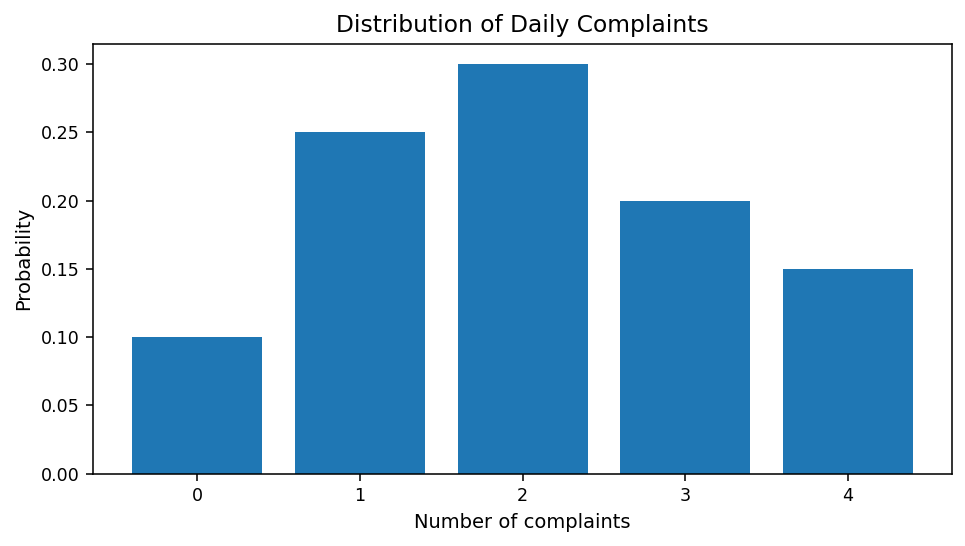

In [10]:
plt.figure(figsize=(7,4))
plt.bar(complaints["x_complaints"], complaints["probability"])
plt.title("Distribution of Daily Complaints", fontsize=12)
plt.xlabel("Number of complaints", fontsize=10)
plt.ylabel("Probability", fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Your answer
What does the expected value tell the manager?
Is the variability high or low?
Would you schedule extra customer service staff tomorrow?

## Part 2. Binomial distribution

An exporting firm sends 8 shipments per week.
The probability that any one shipment is delayed is 0.15.

Let X = number of delayed shipments in a week.

This is a binomial setting because:
- there are a fixed number of trials
- each trial has two outcomes: delay or no delay
- the probability is constant
- shipments are treated as independent

In [11]:
n = 8
p = 0.15

### Task 2A
What is the probability of exactly 2 delays?

In [12]:
prob_2_delays = binom.pmf(2, n, p)
prob_2_delays

np.float64(0.23760419484374998)

### Task 2B
What is the probability of at least 1 delay?

Hint:
P(X >= 1) = 1 - P(X = 0)

In [13]:
prob_at_least_1 = 1 - binom.pmf(0, n, p)
prob_at_least_1

np.float64(0.7275094749609374)

### Task 2C
What is the probability of no more than 2 delays?

In [14]:
prob_no_more_than_2 = binom.cdf(2, n, p)
prob_no_more_than_2

np.float64(0.8947872258203124)

### Task 2D
Compute the mean and variance of the binomial distribution using formulas.

Mean = np
Variance = np(1-p)

In [15]:
mu_binom = n * p
var_binom = n * p * (1 - p)

mu_binom, var_binom

(1.2, 1.02)

### Task 2E
Plot the full binomial distribution.

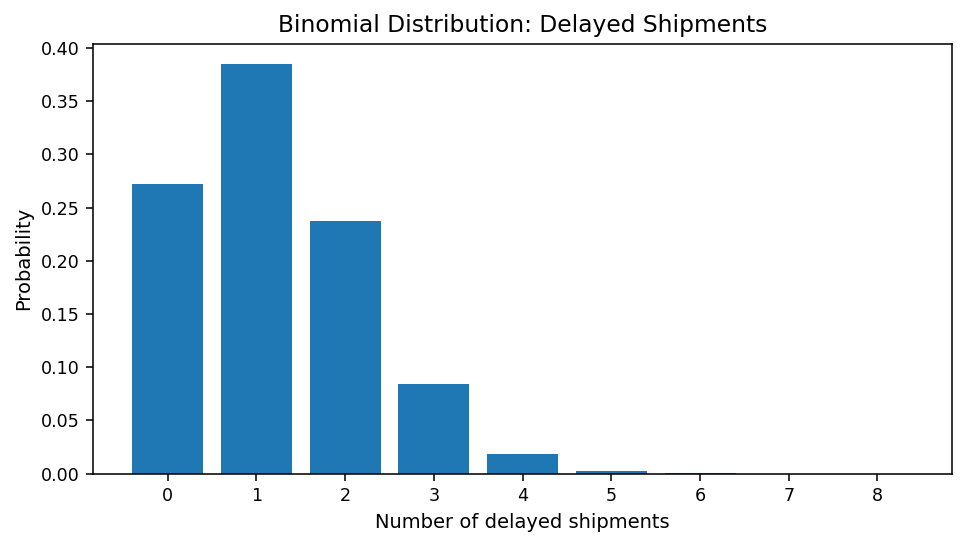

In [16]:
x = np.arange(0, n + 1)
y = binom.pmf(x, n, p)

plt.figure(figsize=(7,4))
plt.bar(x, y)
plt.title("Binomial Distribution: Delayed Shipments", fontsize=12)
plt.xlabel("Number of delayed shipments", fontsize=10)
plt.ylabel("Probability", fontsize=10)
plt.xticks(x, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Your answer
Suppose the firm starts losing money when there are 2 or more delays in a week.
Based on your results, does delay risk look small, moderate, or serious?

## Part 3. Hypergeometric distribution

A quality-control manager inspects a small batch of items.

There are:
- 20 total products in the batch
- 5 defective products
- 4 products selected for inspection without replacement

Let X = number of defective items in the sample.

This is hypergeometric because sampling is without replacement.

In [17]:
N = 20
K = 5
n_sample = 4

### Task 3A
What is the probability that exactly 2 defective items are found?

In [18]:
prob_exactly_2_def = hypergeom.pmf(2, N, K, n_sample)
prob_exactly_2_def

np.float64(0.21671826625386997)

### Task 3B
What is the probability that at least 1 defective item is found?

In [19]:
prob_at_least_1_def = 1 - hypergeom.pmf(0, N, K, n_sample)
prob_at_least_1_def

np.float64(0.7182662538699691)

### Task 3C
Show the whole hypergeometric distribution.

In [20]:
x_h = np.arange(0, n_sample + 1)
y_h = hypergeom.pmf(x_h, N, K, n_sample)

hyper_df = pd.DataFrame({
    "x_defective_found": x_h,
    "probability": y_h
})

hyper_df

,x_defective_found,probability
0,0,0.281734
1,1,0.469556
2,2,0.216718
3,3,0.030960
4,4,0.001032


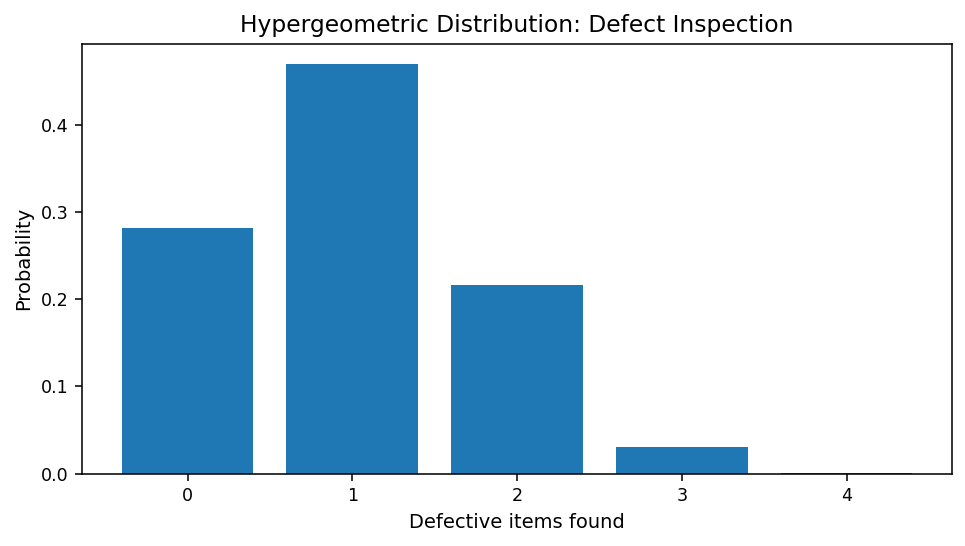

In [21]:
plt.figure(figsize=(7,4))
plt.bar(hyper_df["x_defective_found"], hyper_df["probability"])
plt.title("Hypergeometric Distribution: Defect Inspection", fontsize=12)
plt.xlabel("Defective items found", fontsize=10)
plt.ylabel("Probability", fontsize=10)
plt.xticks(x_h, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Your answer
If the probability of finding at least one defective product is high, what should the manager do?
- continue production normally
- increase inspection
- stop the line and investigate

Briefly explain.

## Part 4. Poisson distribution

A logistics firm tracks the number of customs-document problems per day.

Historical average:
- 0.8 documentation problems per day

Let X = number of documentation problems in a day.

This is a Poisson setting because we count rare events in a fixed time interval.

In [22]:
lam = 0.8

### Task 4A
What is the probability of zero documentation problems tomorrow?

In [23]:
prob_zero_docs = poisson.pmf(0, lam)
prob_zero_docs

np.float64(0.44932896411722156)

### Task 4B
What is the probability of exactly 2 documentation problems?

In [24]:
prob_two_docs = poisson.pmf(2, lam)
prob_two_docs

np.float64(0.14378526851751092)

### Task 4C
What is the probability of at most 1 documentation problem?

In [25]:
prob_at_most_1 = poisson.cdf(1, lam)
prob_at_most_1

np.float64(0.8087921354109989)

### Task 4D
Plot the distribution for values from 0 to 6.

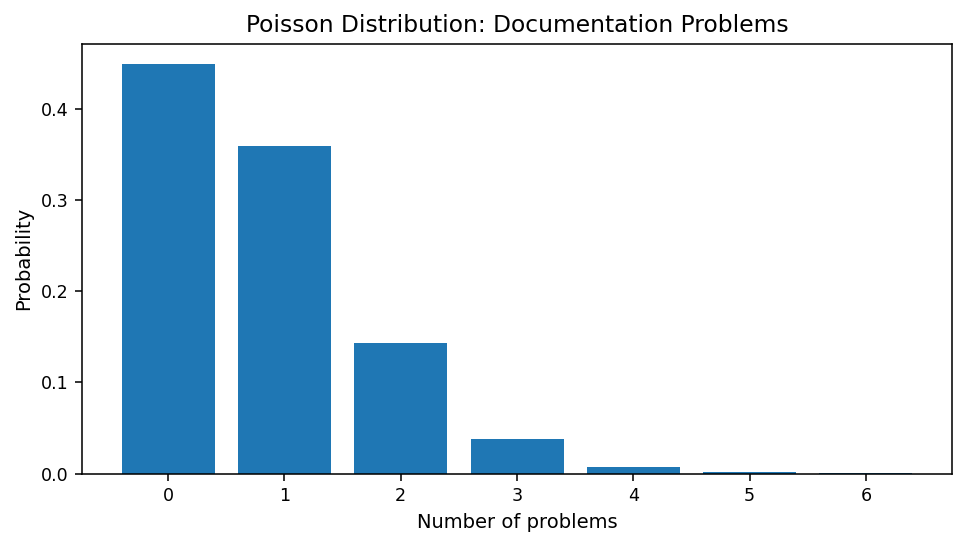

In [26]:
x_p = np.arange(0, 7)
y_p = poisson.pmf(x_p, lam)

plt.figure(figsize=(7,4))
plt.bar(x_p, y_p)
plt.title("Poisson Distribution: Documentation Problems", fontsize=12)
plt.xlabel("Number of problems", fontsize=10)
plt.ylabel("Probability", fontsize=10)
plt.xticks(x_p, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Your answer
If even one documentation problem can delay customs clearance, does this process seem reliable enough?
What operational recommendation would you make?

## Part 5. Short comparison task

Compare the three distributions:
- Binomial
- Hypergeometric
- Poisson

For each one, identify:
1. What is being counted?
2. Are trials independent?
3. Is sampling with or without replacement?
4. What kind of business problem is it useful for?

### Your answer
Write 3 to 5 sentences comparing the three distributions.

## Part 6. Mini decision case

A company faces three risks:
1. Shipment delay risk
2. Defect risk in a small batch
3. Documentation error risk

Based on your probability results from Parts 2, 3, and 4:

- which risk seems most operationally important?
- which one should management address first?
- what concrete action would you recommend?

Write a short answer in 4 to 6 sentences.

## Optional challenge

Change one parameter in each model and see how the conclusions change.

Examples:
- increase shipment delay probability from 0.15 to 0.25
- increase defective items from 5 to 8
- increase average documentation problems from 0.8 to 1.5

Then ask:
How does risk change?
Would your management recommendation change?

## End of lab

Before submitting:
- make sure all cells run
- check that your written answers are complete
- save your notebook in Google Drive